In [38]:
import pandas as pd
import numpy as np
import os

In [39]:
import os
import pandas as pd

DATA_DIR = 'data'

MIRNA_FILENAME = 'Human_TCGA_BRCA_BDGSC_miRNASeq_HS_miR_01_28_2016_BI_Gene_Firehose.cct'
CLINICAL_FILENAME = 'Human_TCGA_BRCA_MS_Clinical_Clinical_01_28_2016_BI_Clinical_Firehose.tsi'

mirna_path = os.path.join(DATA_DIR, MIRNA_FILENAME)
clinical_path = os.path.join(DATA_DIR, CLINICAL_FILENAME)

if not os.path.exists(mirna_path):
    print(f"❌ Error: File not found at: {mirna_path}")
    print(f"📂 Current Working Directory is: {os.getcwd()}")
    print("👉 Hint: Make sure the 'data' folder is in the SAME folder as this notebook.")
    raise FileNotFoundError("Data file missing.")

print(f"Loading data from: {mirna_path} ...")
mirna_df = pd.read_csv(mirna_path, sep='\t')
clinical_df = pd.read_csv(clinical_path, sep='\t')

print("✅ Files loaded successfully!")

Loading data from: data\Human_TCGA_BRCA_BDGSC_miRNASeq_HS_miR_01_28_2016_BI_Gene_Firehose.cct ...
✅ Files loaded successfully!


In [40]:
mirna_df = mirna_df.set_index('attrib_name')
mirna_df_T = mirna_df.T
mirna_df_T = mirna_df_T.reset_index()
mirna_df_T = mirna_df_T.rename(columns={'index': 'SampleID'})

clinical_df = clinical_df.set_index('attrib_name')
clinical_df_T = clinical_df.T
clinical_df_T = clinical_df_T.reset_index()
clinical_df_T = clinical_df_T.rename(columns={'index': 'SampleID'})

mirna_df_T['SampleID'] = mirna_df_T['SampleID'].str[:12]
clinical_df_T['SampleID'] = clinical_df_T['SampleID'].str[:12]

mirna_df_T = mirna_df_T.drop_duplicates(subset='SampleID', keep='first')
clinical_df_T = clinical_df_T.drop_duplicates(subset='SampleID', keep='first')

merged_df = pd.merge(mirna_df_T, clinical_df_T, on='SampleID')

print("Data merged successfully.")
print(f"Merged dataframe shape: {merged_df.shape}")

Data merged successfully.
Merged dataframe shape: (755, 844)


In [41]:
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
import matplotlib.pyplot as plt

In [42]:
TARGET_COLUMN = 'pathology_N_stage'

merged_df[TARGET_COLUMN] = merged_df[TARGET_COLUMN].astype(str).str.lower()

valid_mask = merged_df[TARGET_COLUMN].str.startswith('n0') | merged_df[TARGET_COLUMN].str.startswith('n1')
final_df = merged_df[valid_mask].copy()

final_df.loc[:, 'simple_target'] = np.where(final_df[TARGET_COLUMN].str.startswith('n0'), 0, 1)

mirna_columns = mirna_df.index.tolist()
X_temp = final_df[mirna_columns]
y = final_df['simple_target'].values

X_numeric = X_temp.apply(pd.to_numeric, errors='coerce')
imputer = SimpleImputer(strategy='mean')
X_imputed_array = imputer.fit_transform(X_numeric)

X = pd.DataFrame(X_imputed_array, columns=mirna_columns)
target_names = ['N0', 'N1']

In [43]:
train_matrix, test_matrix, train_label, test_label = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
train_matrix = scaler.fit_transform(train_matrix)
test_matrix = scaler.transform(test_matrix)

In [44]:
print(train_matrix.shape)
print(train_label.shape)
print(test_matrix.shape)
print(test_label.shape)

(492, 823)
(492,)
(123, 823)
(123,)


In [45]:
model = GaussianNB()
model.fit(train_matrix, train_label)

,priors,None
,var_smoothing,1e-09


In [46]:
train_predict = model.predict(train_matrix)
test_predict = model.predict(test_matrix)

In [47]:
print("--- Accuracy (Train) ---")
print(accuracy_score(train_label, train_predict))
print("--- Accuracy (Test) ---")
print(accuracy_score(test_label, test_predict))

--- Accuracy (Train) ---
0.6300813008130082
--- Accuracy (Test) ---
0.5203252032520326


In [48]:
print("--- Classification Report (train) ---")
print(classification_report(train_label, train_predict, target_names=target_names, zero_division=0))

--- Classification Report (train) ---
              precision    recall  f1-score   support

          N0       0.91      0.41      0.56       289
          N1       0.53      0.95      0.68       203

    accuracy                           0.63       492
   macro avg       0.72      0.68      0.62       492
weighted avg       0.76      0.63      0.61       492



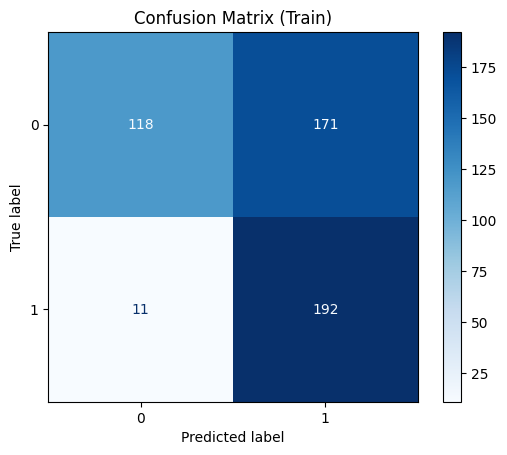

<Figure size 640x480 with 0 Axes>

In [49]:
cm = confusion_matrix(train_label, train_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Train)")
plt.savefig('nb_train_cm.png')
plt.show()
plt.clf()

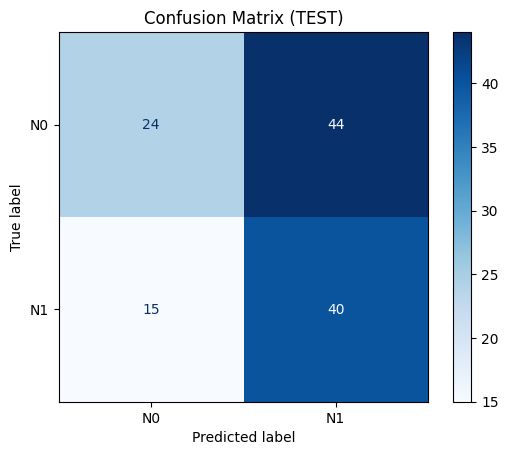

<Figure size 640x480 with 0 Axes>

In [50]:
cm = confusion_matrix(test_label, test_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.savefig('nb_test_cm.png')
plt.title("Confusion Matrix (TEST)")
plt.show()
plt.clf()

In [51]:
pca = PCA(n_components=2)
pca.fit(train_matrix)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [52]:
test_pca_matrix = pca.transform(test_matrix)
train_pca_matrix = pca.transform(train_matrix)

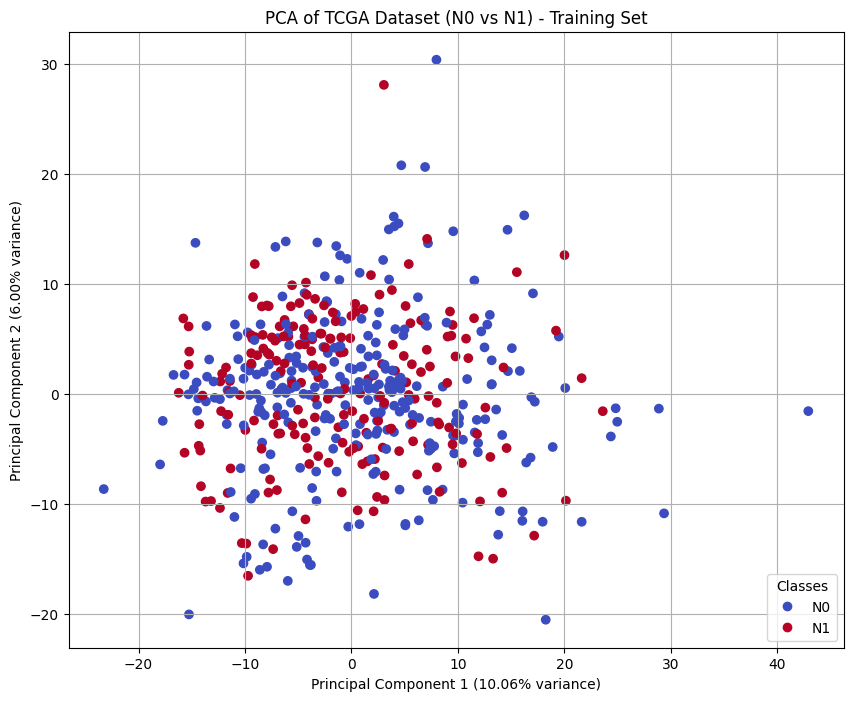

<Figure size 640x480 with 0 Axes>

In [53]:
plt.figure(figsize=(10, 8))
fig = plt.scatter(train_pca_matrix[:, 0], train_pca_matrix[:, 1], c=train_label, cmap='coolwarm')
plt.legend(handles=fig.legend_elements()[0], labels=target_names, loc="lower right", title="Classes")
plt.title('PCA of TCGA Dataset (N0 vs N1) - Training Set')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True)
plt.savefig('pca_scatter_n0_n1.png')
plt.show()
plt.clf()

In [54]:
model = GaussianNB()
model.fit(train_pca_matrix, train_label)

,priors,None
,var_smoothing,1e-09


In [55]:
train_predict = model.predict(train_pca_matrix)
test_predict = model.predict(test_pca_matrix)

In [56]:
print(accuracy_score(train_label, train_predict))
print(accuracy_score(test_label, test_predict))

0.5873983739837398
0.5528455284552846


In [57]:
print(classification_report(test_label, test_predict, target_names=target_names, zero_division=0))

              precision    recall  f1-score   support

          N0       0.55      1.00      0.71        68
          N1       0.00      0.00      0.00        55

    accuracy                           0.55       123
   macro avg       0.28      0.50      0.36       123
weighted avg       0.31      0.55      0.39       123



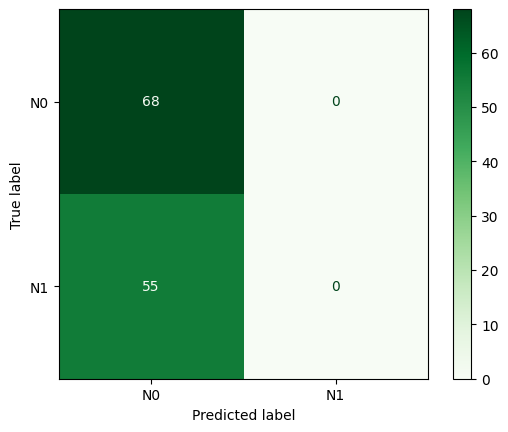

<Figure size 640x480 with 0 Axes>

In [58]:
cm = confusion_matrix(test_label, test_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Greens)
plt.savefig('pca_nb_test_cm.png')
plt.show()
plt.clf()

In [59]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda

In [60]:
model = lda()
model.fit(train_matrix, train_label)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [61]:
test_predict = model.predict(test_matrix)
train_predict = model.predict(train_matrix)

In [62]:
print(classification_report(test_label, test_predict, target_names=target_names, zero_division=0))

              precision    recall  f1-score   support

          N0       0.60      0.60      0.60        68
          N1       0.51      0.51      0.51        55

    accuracy                           0.56       123
   macro avg       0.56      0.56      0.56       123
weighted avg       0.56      0.56      0.56       123



In [63]:
print(classification_report(train_label, train_predict, target_names=target_names, zero_division=0))

              precision    recall  f1-score   support

          N0       0.95      0.95      0.95       289
          N1       0.93      0.92      0.93       203

    accuracy                           0.94       492
   macro avg       0.94      0.94      0.94       492
weighted avg       0.94      0.94      0.94       492



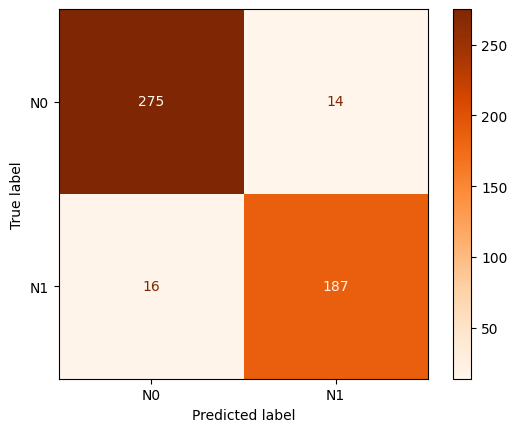

<Figure size 640x480 with 0 Axes>

In [64]:
cm = confusion_matrix(train_label, train_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Oranges)
plt.savefig('lda_train_cm.png')
plt.show()
plt.clf()

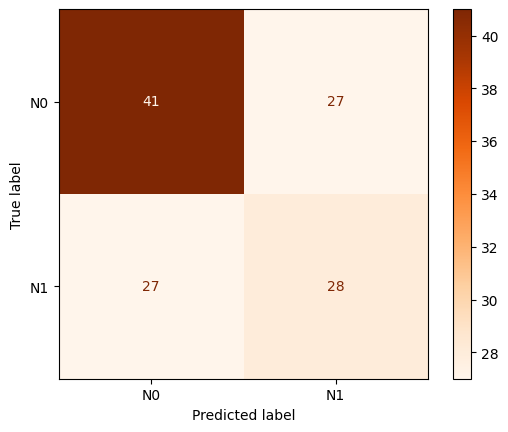

<Figure size 640x480 with 0 Axes>

In [65]:
cm = confusion_matrix(test_label, test_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Oranges)
plt.savefig('lda_test_cm.png')
plt.show()
plt.clf()

In [66]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA


--- Quadratic Discriminant Analysis (QDA) ---
--- Accuracy (Train QDA) ---
1.0
--- Accuracy (Test QDA) ---
0.5121951219512195

--- Classification Report (Train QDA) ---
              precision    recall  f1-score   support

          N0       1.00      1.00      1.00       289
          N1       1.00      1.00      1.00       203

    accuracy                           1.00       492
   macro avg       1.00      1.00      1.00       492
weighted avg       1.00      1.00      1.00       492


--- Classification Report (Test QDA) ---
              precision    recall  f1-score   support

          N0       0.56      0.51      0.54        68
          N1       0.46      0.51      0.48        55

    accuracy                           0.51       123
   macro avg       0.51      0.51      0.51       123
weighted avg       0.52      0.51      0.51       123


--- Confusion Matrix (Train QDA) ---


c:\Users\HYPER_STOCK_TABRIZ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\HYPER_STOCK_TABRIZ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


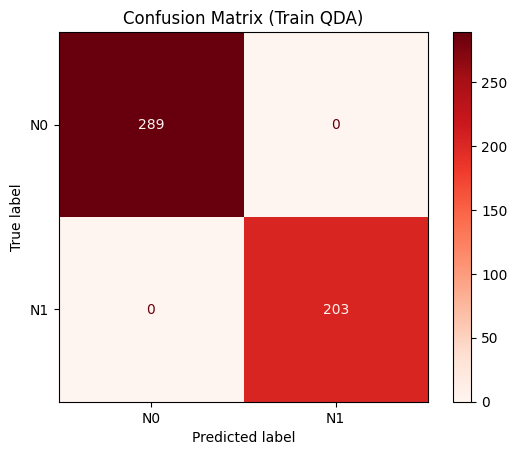


--- Confusion Matrix (Test QDA) ---


<Figure size 640x480 with 0 Axes>

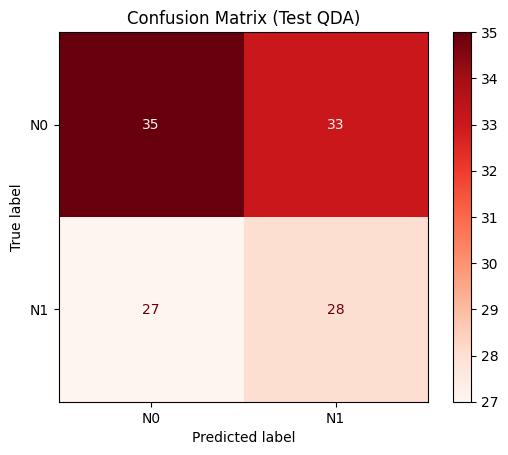


QDA analysis complete. Confusion matrices displayed.


<Figure size 640x480 with 0 Axes>

In [67]:
print("\n--- Quadratic Discriminant Analysis (QDA) ---")

try:
    model_qda = QDA()
    model_qda.fit(train_matrix, train_label)

    train_predict_qda = model_qda.predict(train_matrix)
    test_predict_qda = model_qda.predict(test_matrix)

    print("--- Accuracy (Train QDA) ---")
    print(accuracy_score(train_label, train_predict_qda))
    print("--- Accuracy (Test QDA) ---")
    print(accuracy_score(test_label, test_predict_qda))

    print("\n--- Classification Report (Train QDA) ---")
    print(classification_report(train_label, train_predict_qda, target_names=target_names, zero_division=0))
    print("\n--- Classification Report (Test QDA) ---")
    print(classification_report(test_label, test_predict_qda, target_names=target_names, zero_division=0))

    print("\n--- Confusion Matrix (Train QDA) ---")
    cm_train_qda = confusion_matrix(train_label, train_predict_qda)
    disp_train_qda = ConfusionMatrixDisplay(confusion_matrix=cm_train_qda, display_labels=target_names)
    disp_train_qda.plot(cmap=plt.cm.Reds)
    plt.title("Confusion Matrix (Train QDA)")
    plt.savefig('qda_train_cm.png')
    plt.show()
    plt.clf()

    print("\n--- Confusion Matrix (Test QDA) ---")
    cm_test_qda = confusion_matrix(test_label, test_predict_qda)
    disp_test_qda = ConfusionMatrixDisplay(confusion_matrix=cm_test_qda, display_labels=target_names)
    disp_test_qda.plot(cmap=plt.cm.Reds)
    plt.title("Confusion Matrix (Test QDA)")
    plt.savefig('qda_test_cm.png')
    plt.show()
    plt.clf()

    print("\nQDA analysis complete. Confusion matrices displayed.")

except Exception as e:
    print("\n--- ERROR in QDA ---")
    print("QDA failed as expected due to high dimensionality.")
    print(f"Error message: {e}")